# 14 — Exploratory presentation results

**Exploratory analysis. These analyses do not change the confirmatory H1–H6 verdicts
from Notebook 13.**

Builds on Notebook 12 (security/care/appearance deep-dive): overlapping tables are
**reused**, not recomputed. New pieces: thematic richness, attention waterfall,
dose-response curves, residual Goodreads quadrants, genre/era heatmap,
representative examples.

Stage 10 `06_goodreads_validation` remains the taxonomy-era baseline and is not edited.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage10_correlation_analysis.analysis import models as mdl
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import presentation as pres
from src.stage11_refined_construct_analysis.analysis import thematic_richness as tr

ctx = nh.setup("14_exploratory_presentation_results")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
coverage = nh.load_construct_coverage(cfg)

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()
work = pres.add_year_bin(work)
work = pres.residualize_outcomes(work)
work = pres.residual_goodreads_quadrants(work)

master = nh.load_master(cfg)

# Load NB12 / NB13 artifacts where available
def try_load(notebook: str, name: str) -> pd.DataFrame:
    try:
        df = pres.load_notebook_table(cfg, notebook, name)
        print(f"  loaded {notebook}/{name} ({len(df):,} rows)")
        return df
    except FileNotFoundError as exc:
        print(f"  missing {notebook}/{name}: {exc}")
        return pd.DataFrame()


nb12_traj = try_load("12_exploratory_security_care_appearance", "strict_moderate_broad_trajectories")
nb12_promise = try_load("12_exploratory_security_care_appearance", "promise_type_comparison")
nb12_forest = try_load("12_exploratory_security_care_appearance", "topic_forest_broad_families")
nb12_presence = try_load("12_exploratory_security_care_appearance", "presence_vs_intensity")
nb12_danger = try_load("12_exploratory_security_care_appearance", "danger_x_protection_interaction")
nb12_danger_quad = try_load("12_exploratory_security_care_appearance", "danger_x_protection_quadrants")
nb12_care_app = try_load("12_exploratory_security_care_appearance", "care_x_appearance_quadrants")
nb13_effects = try_load("13_final_statistical_tests", "final_all_effects")
nb11_stab = try_load("11_refined_robustness", "stability_summary")
nb11_comp = try_load("11_refined_robustness", "headline_component_effects")

  loaded 12_exploratory_security_care_appearance/strict_moderate_broad_trajectories (21 rows)
  loaded 12_exploratory_security_care_appearance/promise_type_comparison (10 rows)
  loaded 12_exploratory_security_care_appearance/topic_forest_broad_families (55 rows)
  loaded 12_exploratory_security_care_appearance/presence_vs_intensity (21 rows)
  loaded 12_exploratory_security_care_appearance/danger_x_protection_interaction (3 rows)
  loaded 12_exploratory_security_care_appearance/danger_x_protection_quadrants (12 rows)
  loaded 12_exploratory_security_care_appearance/care_x_appearance_quadrants (4 rows)
  loaded 13_final_statistical_tests/final_all_effects (21 rows)
  loaded 11_refined_robustness/stability_summary (17 rows)
  loaded 11_refined_robustness/headline_component_effects (4 rows)


## Section 1 — What actually differs most?

Forest of refined features (from NB13 when available, else recomputed Cliff's δ).

,hypothesis,feature,label,status,measurement_gate,verdict,expected_sign,cliffs_delta,ci_low,ci_high,magnitude,epsilon_squared,kw_p_value,spearman_rho,quality_beta,quality_se,quality_p,quality_ci_low,quality_ci_high,reach_beta,reach_p,n_clusters,note,book_boot_ci_low,book_boot_ci_high,kw_q_value,quality_q
11,H3,RAX_appearance_grooming,appearance / grooming,tested,viable,clears_gate,NaN,-0.1424,-0.1701,-0.1143,small,0.0106,0.0000,-0.1000,-3.4644,0.3987,0.0000,-4.2459,-2.6829,21.2397,0.0000,"8,263.0000",,-0.1638,-0.1207,NaN,NaN
7,H1,RAX_explicit_sex,explicit sex,tested,viable,directional_only,NaN,-0.0753,-0.1040,-0.0437,negligible,0.0028,0.0000,-0.0527,0.2094,0.3813,0.5828,-0.5379,0.9567,22.0320,0.0000,"8,263.0000",,-0.0968,-0.0535,NaN,NaN
5,H6,RARC,refined arc contrast,tested,viable,contradicted,1.0000,-0.0528,-0.0769,-0.0297,negligible,0.0014,0.0000,-0.0372,-0.3952,0.1707,0.0206,-0.7298,-0.0606,-1.6191,0.2286,"8,263.0000",,-0.0762,-0.0299,0.0000,0.0412
4,H5,RLR_darkness_vs_tenderness,darkness vs tenderness,tested,viable,contradicted,1.0000,-0.0315,-0.0620,-0.0012,negligible,0.0005,0.0170,-0.0220,-0.0097,0.0069,0.1603,-0.0232,0.0038,0.1647,0.0042,"8,263.0000",,-0.0522,-0.0114,0.0170,0.1603
8,H1,RAX_nonexplicit_affection,non-explicit affection,tested,viable,directional_only,NaN,0.0343,0.0072,0.0658,negligible,0.0006,0.0090,0.0241,0.8583,0.3023,0.0045,0.2659,1.4508,-13.3675,0.0000,"8,263.0000",,0.0153,0.0571,NaN,NaN
14,H4,RAX_h4_possession_side,possession / control,tested,viable,directional_only,NaN,0.0426,0.0141,0.0695,negligible,0.0009,0.0007,0.0301,0.4613,0.2924,0.1147,-0.1118,1.0344,0.8770,0.7398,"8,263.0000",,0.0223,0.0641,NaN,NaN
9,H3,RAX_h3_emotional_side,emotional security side,tested,viable,directional_only,NaN,0.0602,0.0309,0.0891,negligible,0.0019,0.0000,0.0423,0.2277,0.2423,0.3472,-0.2471,0.7026,3.4698,0.0488,"8,263.0000",,0.0379,0.0804,NaN,NaN
0,H1,RLR_emotional_vs_explicit,emotional vs explicit ratio,tested,viable,"directionally consistent, effect below threshold",1.0000,0.0986,0.0671,0.1274,negligible,0.0049,0.0000,0.0695,-0.0075,0.0022,0.0005,-0.0118,-0.0033,-0.2038,0.0000,"8,263.0000",,0.0779,0.1202,0.0000,0.0022
16,H5,RAX_external_danger_crisis,external danger / crisis,tested,viable,clears_gate,NaN,0.1159,0.0890,0.1425,small,0.0068,0.0000,0.0816,0.1711,0.1786,0.3382,-0.1790,0.5212,-3.1202,0.0522,"8,263.0000",,0.0937,0.1364,NaN,NaN
15,H5,RAX_tenderness_core,tenderness core,tested,viable,clears_gate,NaN,0.1347,0.1040,0.1646,small,0.0092,0.0000,0.0950,0.5447,0.1195,0.0000,0.3105,0.7789,3.6883,0.0005,"8,263.0000",,0.1122,0.1536,NaN,NaN


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/presentation_forest.csv  (12 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/presentation_forest.png


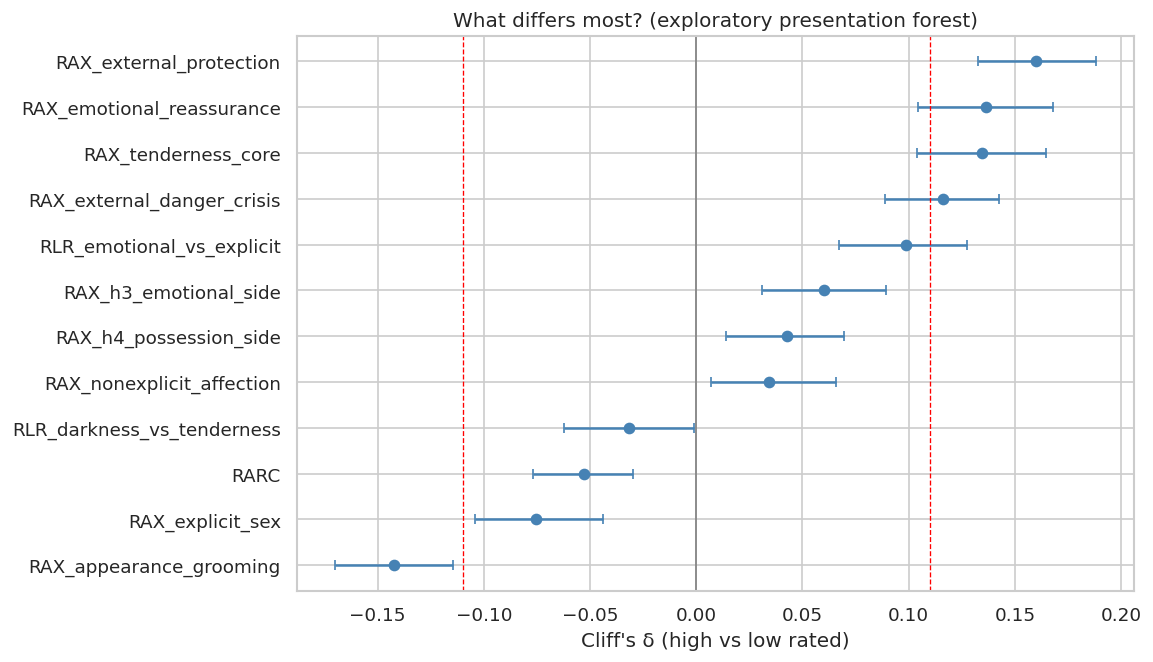

In [3]:
HEADLINE = list(pres.HEADLINE_THEMES_FOR_HEATMAP) + [
    "RAX_emotional_reassurance",
    "RAX_repair",
    "RLR_emotional_vs_explicit",
    "RLR_darkness_vs_tenderness",
]
HEADLINE = list(dict.fromkeys(HEADLINE))

if len(nb13_effects):
    forest = nb13_effects[nb13_effects["feature"].isin(HEADLINE)].copy()
else:
    forest = nh.cliffs_delta_table(work, HEADLINE, n_boot=400, seed=42)
    forest["measurement_gate"] = [nh.gate_for_feature(coverage, f) for f in forest["feature"]]

forest = forest.dropna(subset=["cliffs_delta"])
forest = forest[forest.get("measurement_gate", "viable") != "unmeasurable"] if "measurement_gate" in forest.columns else forest
forest = forest.sort_values("cliffs_delta")
display(forest.round(4))
ctx.save_table(forest, "presentation_forest")

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(forest))
lo = forest["ci_low"] if "ci_low" in forest.columns else forest["cliffs_delta"]
hi = forest["ci_high"] if "ci_high" in forest.columns else forest["cliffs_delta"]
ax.errorbar(
    forest["cliffs_delta"],
    y,
    xerr=[forest["cliffs_delta"] - lo, hi - forest["cliffs_delta"]],
    fmt="o",
    color="steelblue",
    capsize=3,
)
ax.axvline(0, color="gray", lw=1)
ax.axvline(GATE, color="red", ls="--", lw=0.8)
ax.axvline(-GATE, color="red", ls="--", lw=0.8)
ax.set_yticks(y)
labels = forest["feature"].tolist()
ax.set_yticklabels(labels)
ax.set_xlabel("Cliff's δ (high vs low rated)")
ax.set_title("What differs most? (exploratory presentation forest)")
ctx.save_figure(fig, "presentation_forest")
plt.show()

## Section 2 — Are better romances simply about more things?

**Exploratory question (not a confirmatory finding):**

> Do higher-rated romance novels distribute narrative attention across a broader range
> of themes, or are they more concentrated around a few dominant themes?

This is different from asking *which* themes differ. Here we ask how *varied* the
thematic composition of an entire book is.

**Do not count non-zero topics.** Notebook 00 shows the median BERTopic topic is present
in ~96.5% of books; longer books also get more chances to touch topics. We instead use:

| Measure | Richer book means |
| --- | --- |
| Shannon topic entropy \(H\) | higher |
| Effective number of themes \(e^H\) | higher (presentation-friendly) |
| Top-10 concentration | lower |
| Rarefied richness (same sentence budget) | higher |

Three resolutions: **(A)** fine-grained topics, **(B)** taxonomy leaves (**primary**),
**(C)** renormalized presentation constructs (`ATTENTION_THEMES`).

In [4]:
work, richness_meta = tr.compute_all_richness(cfg, work, seed=42, length_quantile=0.10)
print("Richness meta:", richness_meta)

metric_cols = [
    c
    for c in (
        "topic_H",
        "topic_n_eff",
        "topic_top10",
        "taxonomy_H",
        "taxonomy_n_eff",
        "taxonomy_top10",
        "construct_H",
        "construct_n_eff",
        "construct_top10",
        "rare_topic_n_eff",
        "rare_taxonomy_n_eff",
        "rare_construct_n_eff",
        "rarefaction_depth",
    )
    if c in work.columns
]
richness_book = work[["book_id", "rating_class", "rating_shrunk", "n_sentences"] + metric_cols].copy()
display(richness_book[metric_cols].describe().round(3))
ctx.save_table(richness_book, "thematic_richness_book_metrics")
pd.Series(richness_meta).to_frame("value").to_csv(
    ctx.tables_dir / "thematic_richness_meta.csv"
)

Richness meta: {'rarefaction_depth': 3098, 'n_rarefaction_eligible': 14364, 'n_topics': 373, 'n_leaves': 45, 'n_constructs': 10, 'length_quantile': 0.1, 'seed': 42}


,topic_H,topic_n_eff,topic_top10,taxonomy_H,taxonomy_n_eff,taxonomy_top10,construct_H,construct_n_eff,construct_top10,rare_topic_n_eff,rare_taxonomy_n_eff,rare_construct_n_eff,rarefaction_depth
count,"15,999.0000","15,999.0000","15,999.0000","15,999.0000","15,999.0000","15,999.0000","15,999.0000","15,999.0000","15,999.0000","14,364.0000","14,364.0000","14,364.0000","14,364.0000"
mean,5.1380,173.2660,0.2340,3.2150,25.0280,0.6320,1.5540,4.7900,1.0000,171.2690,25.0580,4.7630,"3,098.0000"
std,0.2150,26.7890,0.0520,0.1090,2.1260,0.0400,0.1600,0.7060,0.0180,22.2400,1.9130,0.7050,0.0000
min,-0.0000,1.0000,0.1370,-0.0000,1.0000,0.5010,0.0000,1.0000,0.0000,8.3460,4.1800,1.7050,"3,098.0000"
25%,5.0800,160.7640,0.2020,3.1770,23.9770,0.6050,1.4650,4.3270,1.0000,160.0750,23.9760,4.2810,"3,098.0000"
50%,5.1780,177.2590,0.2250,3.2280,25.2400,0.6310,1.5850,4.8800,1.0000,173.9000,25.1910,4.8490,"3,098.0000"
75%,5.2520,190.9680,0.2530,3.2720,26.3750,0.6570,1.6710,5.3150,1.0000,186.1330,26.3180,5.2910,"3,098.0000"
max,5.5050,245.9080,1.0000,3.4440,31.3030,1.0000,1.9200,6.8180,1.0000,237.6740,31.5280,6.8040,"3,098.0000"


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_book_metrics.csv  (15,999 rows)


### Plot 1 — Effective theme number by rating tier

Taxonomy \(e^H\) is the headline exploratory measure; topic and top-10 concentration
sit beside it for context.

/tmp/ipykernel_223185/1535514311.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Lower rated", "Mid", "Higher rated"])


/tmp/ipykernel_223185/1535514311.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Lower rated", "Mid", "Higher rated"])


/tmp/ipykernel_223185/1535514311.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Lower rated", "Mid", "Higher rated"])


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/richness_by_rating_tier.png


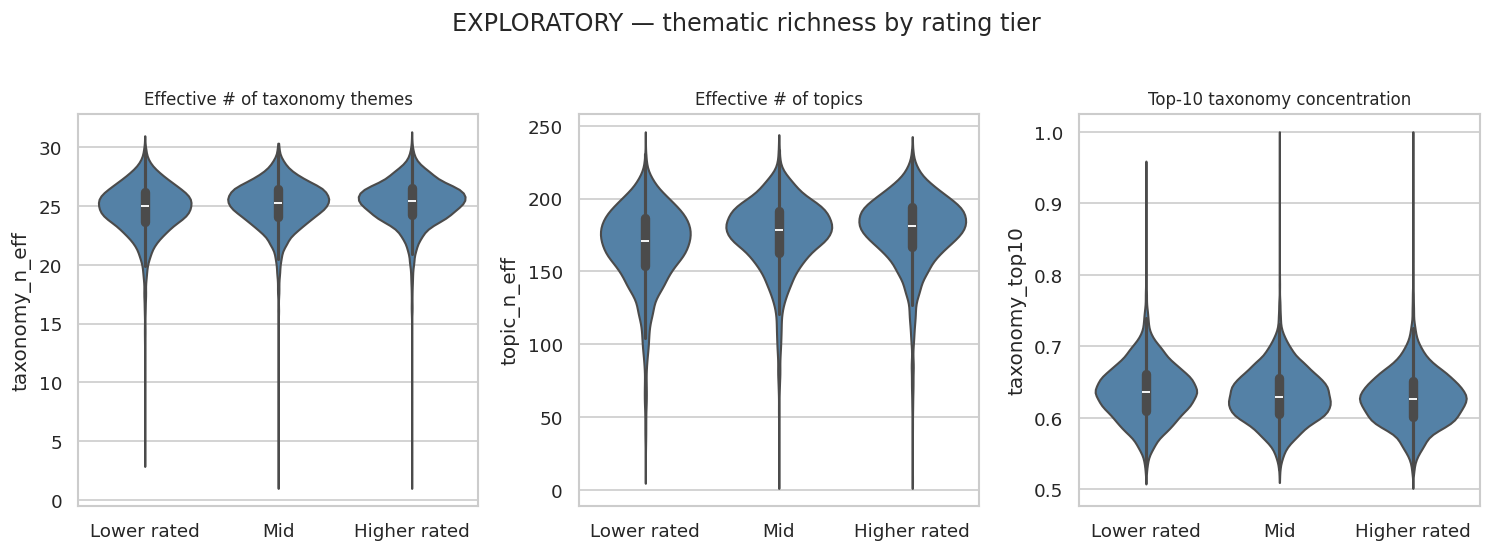

,taxonomy_n_eff,topic_n_eff,construct_n_eff,taxonomy_top10
rating_class,,,,
low_rate,24.7700,167.4800,4.7600,0.6400
mid_rate,25.0900,174.7700,4.8000,0.6300
high_rate,25.2300,177.7600,4.8100,0.6300


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_tier_means.csv  (3 rows)


In [5]:
tier_order = ["low_rate", "mid_rate", "high_rate"]
_RICHNESS_HUMAN = {
    "taxonomy_n_eff": "Effective # of taxonomy themes",
    "topic_n_eff": "Effective # of topics",
    "taxonomy_top10": "Top-10 taxonomy concentration",
}
plot_specs = [
    ("taxonomy_n_eff", _RICHNESS_HUMAN.get("taxonomy_n_eff", "Taxonomy effective # (primary)")),
    ("topic_n_eff", _RICHNESS_HUMAN.get("topic_n_eff", "Topic effective #")),
    ("taxonomy_top10", _RICHNESS_HUMAN.get("taxonomy_top10", "Taxonomy top-10 concentration")),
]
plot_specs = [(c, t) for c, t in plot_specs if c in work.columns]

fig, axes = plt.subplots(1, len(plot_specs), figsize=(4.2 * max(len(plot_specs), 1), 4.5))
if len(plot_specs) == 1:
    axes = [axes]
for ax, (col, title) in zip(axes, plot_specs):
    sub = work[["rating_class", col]].dropna()
    sub = sub[sub["rating_class"].isin(tier_order)]
    sns.violinplot(
        data=sub,
        x="rating_class",
        y=col,
        order=tier_order,
        inner="box",
        cut=0,
        ax=ax,
        color="steelblue",
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Lower rated", "Mid", "Higher rated"])
fig.suptitle("EXPLORATORY — thematic richness by rating tier", y=1.02)
fig.tight_layout(pad=1.1)
ctx.save_figure(fig, "richness_by_rating_tier")
plt.show()

# Tier means for the slide footnote
tier_means = (
    work.loc[work["rating_class"].isin(tier_order)]
    .groupby("rating_class")[
        [c for c in ("taxonomy_n_eff", "topic_n_eff", "construct_n_eff", "taxonomy_top10") if c in work.columns]
    ]
    .mean()
    .reindex(tier_order)
)
display(tier_means.round(2))
ctx.save_table(tier_means.reset_index(), "thematic_richness_tier_means")

### Cliff's δ (high vs low)

Positive δ on \(n_{\mathrm{eff}}\) ⇒ a randomly chosen high-rated book tends to be more
thematically diverse. For top-10 concentration the interesting sign is **negative**
(less dominated by a few themes).

In [6]:
cliff_feats = [f for f in tr.RICHNESS_CLIFF_FEATURES if f in work.columns]
rich_cliffs = nh.cliffs_delta_table(work, cliff_feats, n_boot=400, seed=42)
rich_cliffs["note"] = rich_cliffs["feature"].map(
    lambda f: "lower=richer" if "top10" in str(f) else "higher=richer"
)
display(rich_cliffs.round(4))
ctx.save_table(rich_cliffs, "thematic_richness_cliffs_delta")

,feature,cliffs_delta,ci_low,ci_high,magnitude,n_high,n_low,mean_high,mean_low,note
0,topic_n_eff,0.2440,0.2227,0.2639,small,5086,5389,177.7577,167.4819,higher=richer
1,taxonomy_n_eff,0.1396,0.1179,0.1617,small,5086,5389,25.2336,24.7725,higher=richer
2,construct_n_eff,0.0388,0.0162,0.0611,negligible,5086,5389,4.8098,4.7638,higher=richer
3,topic_top10,-0.1997,-0.2212,-0.1787,small,5086,5389,0.2274,0.2416,lower=richer
4,taxonomy_top10,-0.1310,-0.1520,-0.1088,small,5086,5389,0.6282,0.6366,lower=richer
5,construct_top10,0.0138,-0.0033,0.0323,negligible,5086,5389,0.9994,1.0000,lower=richer
6,rare_topic_n_eff,0.2034,0.1789,0.2279,small,4687,4627,174.6365,167.1584,higher=richer
7,rare_taxonomy_n_eff,0.1143,0.0904,0.1389,small,4687,4627,25.2292,24.8651,higher=richer
8,rare_construct_n_eff,0.0538,0.0297,0.0781,negligible,4687,4627,4.7947,4.7261,higher=richer


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_cliffs_delta.csv  (9 rows)


### Length-controlled OLS

Among books of comparable length, era, and genre, does thematic diversity still track
rating? Author-clustered SEs; reliability weights on quality.

In [7]:
ols_features = [
    c
    for c in (
        "taxonomy_n_eff",
        "topic_n_eff",
        "construct_n_eff",
        "rare_taxonomy_n_eff",
    )
    if c in work.columns
]
controls = [c for c in ("n_sentences", "publication_year") if c in work.columns]
ols_rows = []
for feat in ols_features:
    fit = mdl.fit_ols(
        work,
        outcome="rating_shrunk",
        predictors=[feat, *controls],
        categorical=("genre_group",) if "genre_group" in work.columns else (),
        cluster="author_id" if "author_id" in work.columns else None,
        weights="reliability" if "reliability" in work.columns else None,
        name=f"richness_{feat}",
    )
    coef = fit.coefficients[fit.coefficients["term"] == feat].iloc[0]
    ols_rows.append(
        {
            "feature": feat,
            "coefficient": float(coef["coefficient"]),
            "std_error": float(coef["std_error"]),
            "p_value": float(coef["p_value"]),
            "ci_low": float(coef["ci_low"]),
            "ci_high": float(coef["ci_high"]),
            "n_obs": fit.n_obs,
            "n_clusters": fit.n_clusters,
            "r_squared": fit.r_squared,
        }
    )
rich_ols = pd.DataFrame(ols_rows)
display(rich_ols.round(4))
ctx.save_table(rich_ols, "thematic_richness_ols")

,feature,coefficient,std_error,p_value,ci_low,ci_high,n_obs,n_clusters,r_squared
0,taxonomy_n_eff,0.0024,0.0013,0.0651,-0.0001,0.0049,15999,8263,0.0889
1,topic_n_eff,0.0007,0.0001,0.0000,0.0004,0.0009,15999,8263,0.0945
2,construct_n_eff,0.0166,0.0044,0.0002,0.0080,0.0252,15999,8263,0.0918
3,rare_taxonomy_n_eff,0.0007,0.0014,0.6083,-0.0020,0.0034,14364,7601,0.0834


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_ols.csv  (4 rows)


### Rarefaction check

Every eligible book contributes exactly the same number of sentences
(10th percentile of corpus length). Does taxonomy richness still differ by tier?

Rarefaction depth=3,098 sentences; N eligible=14,364 / 15,999


,taxonomy_n_eff,rare_taxonomy_n_eff,rare_topic_n_eff
rating_class,,,
low_rate,24.9910,24.8650,167.1580
mid_rate,25.2090,25.0750,171.9090
high_rate,25.3640,25.2290,174.6360


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_rarefaction.csv  (3 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/richness_rarefaction_by_tier.png


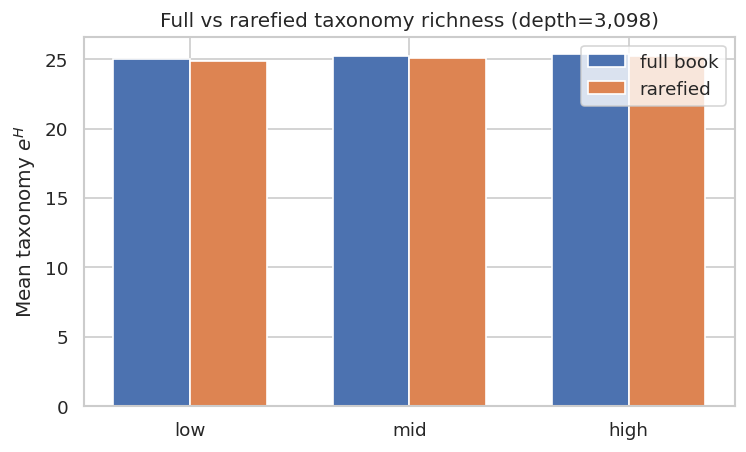

In [8]:
if "rare_taxonomy_n_eff" in work.columns and richness_meta.get("rarefaction_depth"):
    depth = richness_meta["rarefaction_depth"]
    eligible = work.dropna(subset=["rare_taxonomy_n_eff"])
    print(
        f"Rarefaction depth={depth:,} sentences; "
        f"N eligible={len(eligible):,} / {len(work):,}"
    )
    rare_tier = (
        eligible.loc[eligible["rating_class"].isin(tier_order)]
        .groupby("rating_class")[["taxonomy_n_eff", "rare_taxonomy_n_eff", "rare_topic_n_eff"]]
        .mean()
        .reindex(tier_order)
    )
    display(rare_tier.round(3))
    ctx.save_table(rare_tier.reset_index(), "thematic_richness_rarefaction")

    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(tier_order))
    wbar = 0.35
    ax.bar(x - wbar / 2, rare_tier["taxonomy_n_eff"], width=wbar, label="full book")
    ax.bar(x + wbar / 2, rare_tier["rare_taxonomy_n_eff"], width=wbar, label="rarefied")
    ax.set_xticks(x)
    ax.set_xticklabels(["low", "mid", "high"])
    ax.set_ylabel("Mean taxonomy $e^H$")
    ax.set_title(f"Full vs rarefied taxonomy richness (depth={depth:,})")
    ax.legend()
    ctx.save_figure(fig, "richness_rarefaction_by_tier")
    plt.show()
else:
    print("Rarefaction metrics unavailable — skip.")

### Richness vs the right combination

Does taxonomy breadth still predict rating after the main thematic drivers enter?

In [9]:
drivers = [
    c
    for c in (
        "RAX_h3_emotional_side",
        "RAX_appearance_grooming",
        "RAX_external_danger_crisis",
        "RAX_tenderness_core",
    )
    if c in work.columns
]
driver_rows = []
if "taxonomy_n_eff" in work.columns:
    for name, preds in (
        ("M1_richness_only", ["taxonomy_n_eff", *controls]),
        ("M2_richness_plus_drivers", ["taxonomy_n_eff", *drivers, *controls]),
    ):
        fit = mdl.fit_ols(
            work,
            outcome="rating_shrunk",
            predictors=preds,
            categorical=("genre_group",) if "genre_group" in work.columns else (),
            cluster="author_id" if "author_id" in work.columns else None,
            weights="reliability" if "reliability" in work.columns else None,
            name=name,
        )
        for _, coef in fit.coefficients.iterrows():
            if coef["term"] == "const":
                continue
            driver_rows.append(
                {
                    "model": name,
                    "term": coef["term"],
                    "coefficient": float(coef["coefficient"]),
                    "std_error": float(coef["std_error"]),
                    "p_value": float(coef["p_value"]),
                    "ci_low": float(coef["ci_low"]),
                    "ci_high": float(coef["ci_high"]),
                    "n_obs": fit.n_obs,
                    "r_squared": fit.r_squared,
                }
            )
rich_vs_drivers = pd.DataFrame(driver_rows)
display(rich_vs_drivers.round(4))
ctx.save_table(rich_vs_drivers, "thematic_richness_vs_drivers")

,model,term,coefficient,std_error,p_value,ci_low,ci_high,n_obs,r_squared
0,M1_richness_only,taxonomy_n_eff,0.0024,0.0013,0.0651,-0.0001,0.0049,15999,0.0889
1,M1_richness_only,n_sentences,0.0000,0.0000,0.0000,0.0000,0.0000,15999,0.0889
2,M1_richness_only,publication_year,0.0097,0.0010,0.0000,0.0077,0.0116,15999,0.0889
3,M1_richness_only,genre_group_mystery,0.0605,0.0107,0.0000,0.0396,0.0814,15999,0.0889
4,M1_richness_only,genre_group_other,0.0106,0.0089,0.2302,-0.0067,0.0280,15999,0.0889
5,M1_richness_only,genre_group_paranormal,0.0398,0.0109,0.0003,0.0184,0.0613,15999,0.0889
6,M1_richness_only,genre_group_young_adult,-0.0051,0.0117,0.6645,-0.0281,0.0179,15999,0.0889
7,M2_richness_plus_drivers,taxonomy_n_eff,0.0056,0.0014,0.0001,0.0028,0.0084,15999,0.1113
8,M2_richness_plus_drivers,RAX_h3_emotional_side,0.3734,0.2307,0.1055,-0.0787,0.8255,15999,0.1113
9,M2_richness_plus_drivers,RAX_appearance_grooming,-4.2800,0.4428,0.0000,-5.1480,-3.4121,15999,0.1113


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_vs_drivers.csv  (18 rows)


### Nonlinear check — rating by richness decile

Decile 1 = thematically narrowest; 10 = richest. Look for linear rise, inverted-U, or flat.

,decile,n,richness_mean,outcome_mean,outcome_median,richness_col,outcome_col
0,1,1600,20.8199,3.8874,3.8927,taxonomy_n_eff,rating_shrunk
1,2,1600,23.1887,3.8997,3.9003,taxonomy_n_eff,rating_shrunk
2,3,1600,23.9652,3.9178,3.9072,taxonomy_n_eff,rating_shrunk
3,4,1600,24.5244,3.9191,3.9139,taxonomy_n_eff,rating_shrunk
4,5,1600,25.0106,3.9243,3.9177,taxonomy_n_eff,rating_shrunk
5,6,1599,25.4599,3.9295,3.9199,taxonomy_n_eff,rating_shrunk
6,7,1600,25.9016,3.9386,3.9275,taxonomy_n_eff,rating_shrunk
7,8,1600,26.3746,3.9406,3.9239,taxonomy_n_eff,rating_shrunk
8,9,1600,26.9540,3.9330,3.9253,taxonomy_n_eff,rating_shrunk
9,10,1600,28.0768,3.9302,3.9237,taxonomy_n_eff,rating_shrunk


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/thematic_richness_deciles.csv  (20 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/richness_decile_rating.png


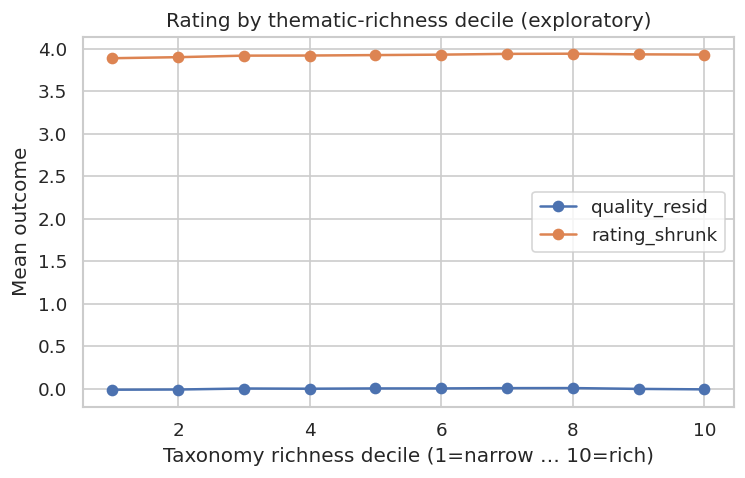

In [10]:
decile_tbl = tr.richness_decile_table(work, "taxonomy_n_eff", "rating_shrunk", n_bins=10)
if "quality_resid" in work.columns:
    decile_resid = tr.richness_decile_table(work, "taxonomy_n_eff", "quality_resid", n_bins=10)
    decile_tbl = pd.concat([decile_tbl, decile_resid], ignore_index=True)
display(decile_tbl.round(4))
ctx.save_table(decile_tbl, "thematic_richness_deciles")

if len(decile_tbl):
    fig, ax = plt.subplots(figsize=(7, 4))
    for outcome, sub in decile_tbl.groupby("outcome_col"):
        ax.plot(sub["decile"], sub["outcome_mean"], marker="o", label=outcome)
    ax.set_xlabel("Taxonomy richness decile (1=narrow … 10=rich)")
    ax.set_ylabel("Mean outcome")
    ax.set_title("Rating by thematic-richness decile (exploratory)")
    ax.legend()
    ctx.save_figure(fig, "richness_decile_rating")
    plt.show()

### Security × richness

Is the pattern “good novels are richer,” or “breadth **with** sustained emotional
reassurance”?

,richness_bin,security_bin,n,mean_rating,median_rating,mean_richness,mean_security,richness_median_cut,security_median_cut
0,high_richness,high_security,4798,3.9386,3.9282,26.6802,0.0473,25.2404,0.0268
1,high_richness,low_security,3202,3.9281,3.9194,26.3632,0.0203,25.2404,0.0268
2,low_richness,high_security,3202,3.9105,3.9076,23.7782,0.0460,25.2404,0.0268
3,low_richness,low_security,4797,3.9091,3.9064,23.3169,0.0195,25.2404,0.0268


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/richness_x_security_quadrants.csv  (4 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/richness_x_security_heatmap.png


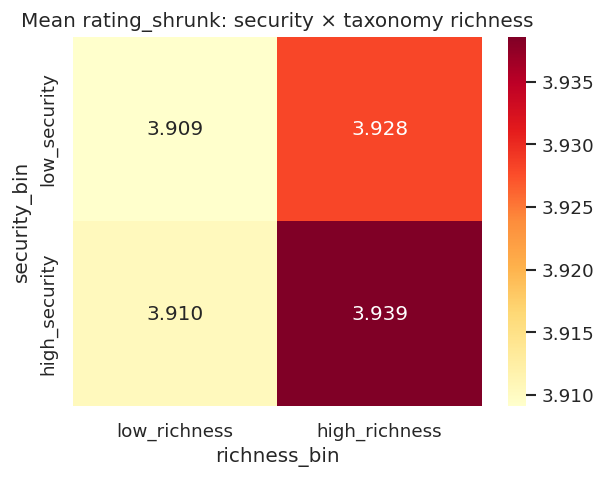

In [11]:
quad = tr.richness_security_quadrants(
    work,
    richness_col="taxonomy_n_eff",
    security_col="RAX_h3_emotional_side" if "RAX_h3_emotional_side" in work.columns else "RAX_emotional_reassurance",
    outcome_col="rating_shrunk",
)
display(quad.round(4))
ctx.save_table(quad, "richness_x_security_quadrants")

if len(quad):
    mat = quad.pivot(index="security_bin", columns="richness_bin", values="mean_rating")
    # Prefer a readable order
    row_order = [r for r in ("low_security", "high_security") if r in mat.index]
    col_order = [c for c in ("low_richness", "high_richness") if c in mat.columns]
    mat = mat.reindex(index=row_order, columns=col_order)
    fig, ax = plt.subplots(figsize=(5.5, 4))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
    ax.set_title("Mean rating_shrunk: security × taxonomy richness")
    ctx.save_figure(fig, "richness_x_security_heatmap")
    plt.show()

### Exploratory conclusion (thematic richness)

From the executed numbers above (exploratory only — do **not** promote to NB13):

- Taxonomy effective-theme number differs by rating tier (Cliff’s δ ≈ **+.14**), and
  fine-grained topic \(e^H\) is larger still (δ ≈ **+.24**), with top-10 concentration
  lower among high-rated books.
- After controlling for length, year, and genre, **taxonomy** richness is only
  marginal (M1 `taxonomy_n_eff` β ≈ 0.0024, p ≈ 0.065); **rarefied** taxonomy
  richness is essentially null (p ≈ 0.61). So length opportunity explains much of
  the leaf-level association.
- Once reassurance, appearance, danger, and tenderness enter (M2), raw
  `taxonomy_n_eff` **strengthens** (β ≈ 0.0066, p &lt; 0.001) — a suppression
  pattern, not attenuation. Richness therefore carries *more* independent
  predictive signal after those drivers are held constant. This remains
  exploratory: rarefaction still nullifies the leaf-level story, and breadth
  alone is not a confirmatory H1–H6 finding.

**Presentation line:** higher-rated romance differs in *which* themes receive
attention (and in security/care mixtures); raw taxonomy breadth also shows a
suppressed partial association after drivers, but rarefied breadth does not
survive, so “more themes” is not a clean confirmatory claim.

## Section 3 — Where does narrative attention move?

Mean theme-share difference (high − low). Shares are compositional: more of one theme
implies less of something else. This is a **percentage-point** view, not Cliff's δ.

,feature,label,mean_high,mean_low,diff_pp,diff,n_high,n_low
0,RAX_h3_emotional_side,emotional reassurance/security,0.0345,0.0321,0.2441,0.0024,5086,5389
1,RAX_relational_darkness,relational darkness / conflict,0.0664,0.0650,0.1477,0.0015,5086,5389
2,RAX_external_protection,enacted protection,0.0032,0.0026,0.0548,0.0005,5086,5389
3,RAX_tenderness_core,tenderness,0.0170,0.0165,0.0500,0.0005,5086,5389
4,RAX_nonexplicit_affection,non-explicit affection,0.0170,0.0165,0.0500,0.0005,5086,5389
5,RAX_external_danger_crisis,external danger,0.0092,0.0089,0.0300,0.0003,5086,5389
6,RAX_repair,repair,0.0000,0.0000,0.0000,0.0000,5086,5389
7,RAX_explicit_sex,explicit sex,0.0000,0.0000,0.0000,0.0000,5086,5389
8,RAX_h4_possession_side,possession / control,0.0024,0.0025,-0.0086,-0.0001,5086,5389
9,RAX_appearance_grooming,appearance / grooming,0.0151,0.0169,-0.1796,-0.0018,5086,5389


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/attention_waterfall.csv  (10 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/attention_waterfall.png


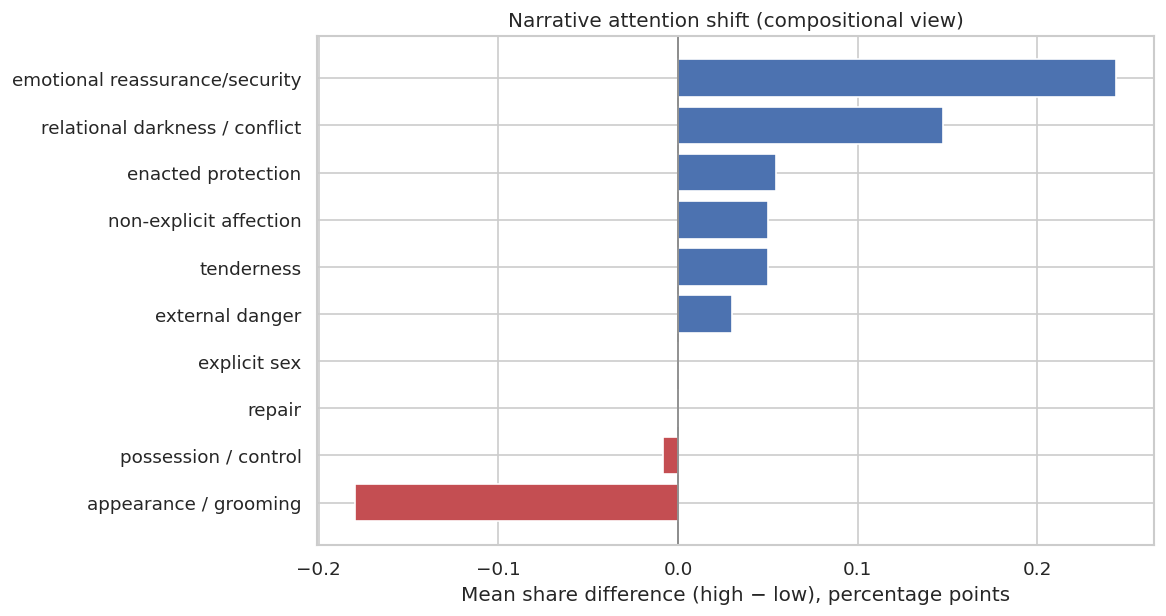

In [12]:
waterfall = pres.attention_waterfall(work)
display(waterfall.round(4))
ctx.save_table(waterfall, "attention_waterfall")

fig, ax = plt.subplots(figsize=(9, 5.5))
order = waterfall.sort_values("diff_pp")
colors = ["#4c72b0" if v >= 0 else "#c44e52" for v in order["diff_pp"]]
ax.barh(order["label"], order["diff_pp"], color=colors)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("Mean share difference (high − low), percentage points")
ax.set_title("Narrative attention shift (compositional view)")
ctx.save_figure(fig, "attention_waterfall")
plt.show()

## Section 4 — Security and care (reuse NB12)

Promise-type comparison and topic forest from Notebook 12, plus topic cards
(id, label, taxonomy, words, example sentence).

In [13]:
if len(nb12_promise):
    display(nb12_promise.round(4))
    ctx.save_table(nb12_promise, "promise_type_comparison_reused")
if len(nb12_forest):
    display(nb12_forest.round(4))
    ctx.save_table(nb12_forest, "topic_forest_broad_families_reused")
if len(nb12_presence):
    display(nb12_presence.round(4))
    ctx.save_table(nb12_presence, "presence_vs_intensity_reused")

# Topic cards for security-family topics appearing in NB12 forest
card_topics = []
if len(nb12_forest) and "topic_id" in nb12_forest.columns:
    card_topics = sorted({int(t) for t in nb12_forest["topic_id"].dropna().tolist()})
elif len(nb12_promise):
    # fall back: H3 KEEP topics from claim hierarchy
    card_topics = [29, 46, 56, 96, 242, 128, 170, 119]
else:
    card_topics = [29, 46, 56, 96, 242, 119]

cards = pd.DataFrame([pres.topic_presentation_card(cfg, tid, master) for tid in card_topics[:25]])
display(cards)
ctx.save_table(cards, "security_care_topic_cards")

,promise_type,n_topics,cliffs_delta,ci_low,ci_high,verdict,note
0,protective_commitment,4,0.2098,0.1890,0.2321,clears_gate,
1,enacted_external_protection,1,0.1597,0.1410,0.1816,clears_gate,
2,non_harm_safety,1,0.1377,0.1175,0.1574,clears_gate,
3,emotional_reassurance,4,0.1045,0.0823,0.1275,directional_only,
4,trust_reliability,1,0.0934,0.0725,0.1128,directional_only,
5,practical_care,5,0.0595,0.0368,0.0791,directional_only,
6,possessive_protection,3,0.0426,0.0223,0.0641,directional_only,
7,belonging_presence,3,-0.0144,-0.0334,0.0066,no reliable effect,
8,long_term_partnership,3,-0.0193,-0.0422,0.0002,no reliable effect,
9,material_provision,5,-0.0402,-0.0616,-0.0202,directional_only,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/promise_type_comparison_reused.csv  (10 rows)


,family,topic_id,topic_label,taxonomy_id,cliffs_delta,ci_low,ci_high,verdict
0,enacted_protection,68,Promising to Set Things Straight,9.2,0.0397,0.0157,0.0612,directional_only
1,enacted_protection,78,Swearing War Before He Takes Her,7.2,0.1648,0.1420,0.1861,clears_gate
2,enacted_protection,87,Threatening Death As A Warning,7.2,0.1619,0.1409,0.1829,clears_gate
3,enacted_protection,107,Gritted Teeth and Clenched Fists,1.1,0.0057,-0.0156,0.0252,no reliable effect
4,enacted_protection,113,Knife Handed Over For Combat,7.2,0.0770,0.0554,0.0995,directional_only
5,enacted_protection,114,Guns Aimed Across The Room,7.2,0.1306,0.1087,0.1539,clears_gate
6,enacted_protection,122,Wound Bleeding and Blood Loss,1.2,0.1288,0.1099,0.1509,clears_gate
7,enacted_protection,119,Offering to Keep Her Safe,4.6,0.1597,0.1410,0.1816,clears_gate
8,enacted_protection,307,Hauling Someone Up The Stairs,4.6,0.0863,0.0672,0.1064,directional_only
9,enacted_protection,363,Asking The Sheriff For Help,10.3,0.0933,0.0725,0.1141,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/topic_forest_broad_families_reused.csv  (55 rows)


,family,level,prevalence,conditional_intensity,unconditional_mean
0,emotional_security,strict,0.9994,0.0243,0.0243
1,emotional_security,moderate,0.9997,0.0575,0.0574
2,emotional_security,broad,0.9997,0.1067,0.1067
3,protective_commitment,strict,0.0000,NaN,0.0000
4,protective_commitment,moderate,0.9977,0.0078,0.0078
5,protective_commitment,broad,0.9995,0.0397,0.0397
6,enacted_protection,strict,0.9862,0.0029,0.0029
7,enacted_protection,moderate,0.9862,0.0029,0.0029
8,enacted_protection,broad,0.9862,0.0029,0.0029
9,practical_care,strict,0.9980,0.0092,0.0092


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/presence_vs_intensity_reused.csv  (21 rows)


,topic_id,topic_label,taxonomy_id,top_words,example_sentence
0,6,Whispered Reassurance,4.6,"whispered, yes, said, asked, softly, thank, fi...",
1,29,Confessing Long-Held Love,4.5,"love, loved, you, loves, too, falling, fall, a...",
2,36,Eagerly Offering to Help,4.6,"help, can, need, helping, you, assistance, you...",Let me help you.”
3,38,Admitting Shared Pain,4.2,"feel, feels, good, felt, feeling, better, make...","Is that what it feels like to you?"" """
4,45,Reassured Everything Will Be Fine,4.6,"fine, okay, everything, right, be, all, honey,...",Everything’s going to be fine.”
5,46,Asking Someone to Trust You,4.6,"trust, trusted, betrayed, betray, trusting, me...",Trust me.”
6,56,Promising Never to Hurt You,4.6,"hurt, hurting, harm, mean, never, won, you, wa...",I have a tendency to hurt myself.
7,59,Mother's Disapproval Looms,5.1,"mother, mom, mama, daughter, your, mum, my, mo...",This is your mother.
8,61,Planning to Exchange Rings,8.3a,"ring, necklace, finger, diamond, stone, jewelr...",
9,65,Declaring A True Partnership,4.5,"date, dating, together, each, we, other, dated...","We have often been together in public."" """


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/security_care_topic_cards.csv  (25 rows)


## Section 5 — Appearance

Refined appearance/grooming vs Stage 10 baseline and NB11 robustness variants.

In [14]:
appearance_rows = []
if len(nb13_effects):
    row = nb13_effects[nb13_effects["feature"] == "RAX_appearance_grooming"]
    if len(row):
        appearance_rows.append(
            {
                "source": "refined_strict_nb13",
                "cliffs_delta": float(row.iloc[0]["cliffs_delta"]),
                "ci_low": float(row.iloc[0]["ci_low"]),
                "ci_high": float(row.iloc[0]["ci_high"]),
                "verdict": row.iloc[0].get("verdict"),
            }
        )
if len(nb11_comp):
    sub = nb11_comp[nb11_comp["feature"].astype(str).str.contains("appearance", case=False, na=False)]
    for _, r in sub.iterrows():
        appearance_rows.append(
            {
                "source": f"nb11:{r.get('spec', r.get('mode', 'component'))}",
                "cliffs_delta": r.get("cliffs_delta"),
                "ci_low": r.get("ci_low"),
                "ci_high": r.get("ci_high"),
                "verdict": r.get("verdict"),
            }
        )
if len(nb11_stab):
    sub = nb11_stab[nb11_stab["feature"].astype(str).str.contains("appearance", case=False, na=False)]
    for _, r in sub.iterrows():
        appearance_rows.append(
            {
                "source": "nb11_stability",
                "cliffs_delta": r.get("min_abs_delta"),
                "ci_low": np.nan,
                "ci_high": np.nan,
                "verdict": f"sign_stable={r.get('sign_stable')}; clears_gate={r.get('any_clears_gate')}",
            }
        )
# Stage 10 freeze retained in config for cross-reference only
_ = cfg.section("stage10_delta_freeze") or {}
appearance_df = pd.DataFrame(appearance_rows)
display(appearance_df)
ctx.save_table(appearance_df, "appearance_summary")

,source,cliffs_delta,ci_low,ci_high,verdict
0,refined_strict_nb13,-0.1424,-0.1701,-0.1143,clears_gate
1,nb11:component,-0.1424,-0.1669,-0.1205,clears_gate
2,nb11_stability,0.1237,NaN,NaN,sign_stable=True; clears_gate=True


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/appearance_summary.csv  (3 rows)


## Section 6 — Strict → broad sensitivity (reuse NB12)

,family,level,feature,n_topics,cliffs_delta,ci_low,ci_high,verdict,note
0,emotional_security,strict,EXP_emotional_security_strict,10,0.0377,0.0164,0.0583,directional_only,
1,emotional_security,moderate,EXP_emotional_security_moderate,29,0.0642,0.0412,0.0888,directional_only,
2,emotional_security,broad,EXP_emotional_security_broad,45,0.1015,0.0787,0.1225,directional_only,
3,protective_commitment,strict,EXP_protective_commitment_strict,0,NaN,NaN,NaN,unmeasurable,zero topics
4,protective_commitment,moderate,EXP_protective_commitment_moderate,5,0.1687,0.1487,0.1890,clears_gate,
5,protective_commitment,broad,EXP_protective_commitment_broad,14,0.0003,-0.0205,0.0238,no reliable effect,
6,enacted_protection,strict,EXP_enacted_protection_strict,1,0.1597,0.1410,0.1816,clears_gate,
7,enacted_protection,moderate,EXP_enacted_protection_moderate,3,0.1597,0.1410,0.1816,clears_gate,
8,enacted_protection,broad,EXP_enacted_protection_broad,10,0.1597,0.1410,0.1816,clears_gate,
9,practical_care,strict,EXP_practical_care_strict,4,0.0573,0.0353,0.0770,directional_only,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/strict_moderate_broad_trajectories_reused.csv  (21 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/strict_moderate_broad_trajectories.png


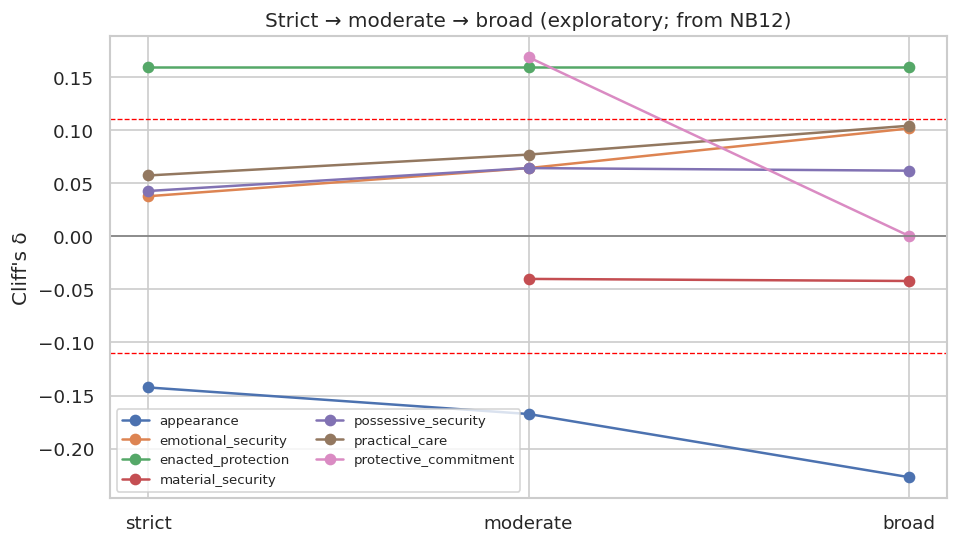

In [15]:
if len(nb12_traj):
    display(nb12_traj.round(4))
    ctx.save_table(nb12_traj, "strict_moderate_broad_trajectories_reused")
    fig, ax = plt.subplots(figsize=(9, 5))
    for family, sub in nb12_traj.groupby("family"):
        sub = sub.set_index("level").reindex(["strict", "moderate", "broad"])
        ax.plot(["strict", "moderate", "broad"], sub["cliffs_delta"], marker="o", label=family)
    ax.axhline(0, color="gray", lw=1)
    ax.axhline(GATE, color="red", ls="--", lw=0.8)
    ax.axhline(-GATE, color="red", ls="--", lw=0.8)
    ax.set_ylabel("Cliff's δ")
    ax.set_title("Strict → moderate → broad (exploratory; from NB12)")
    ax.legend(fontsize=8, ncol=2)
    ctx.save_figure(fig, "strict_moderate_broad_trajectories")
    plt.show()
else:
    print("NB12 trajectories missing — skip Section 6 plot.")

## Section 7 — Dose-response curves

Decile of theme share vs residualized quality (after year/length/genre).

,decile,n,feature_mean,outcome_mean,outcome_median,feature,outcome
0,1,1600,0.0136,-0.0082,-0.0061,RAX_h3_emotional_side,quality_resid
1,2,1600,0.0176,-0.0045,-0.0096,RAX_h3_emotional_side,quality_resid
2,3,1600,0.0201,-0.0009,-0.0097,RAX_h3_emotional_side,quality_resid
3,4,1600,0.0226,-0.0017,-0.0073,RAX_h3_emotional_side,quality_resid
4,5,1600,0.0253,-0.0014,-0.0054,RAX_h3_emotional_side,quality_resid
5,6,1599,0.0287,-0.0102,-0.0113,RAX_h3_emotional_side,quality_resid
6,7,1600,0.0334,-0.0066,-0.0074,RAX_h3_emotional_side,quality_resid
7,8,1600,0.0407,-0.0003,-0.0051,RAX_h3_emotional_side,quality_resid
8,9,1600,0.0526,0.0142,0.0058,RAX_h3_emotional_side,quality_resid
9,10,1600,0.0783,0.0197,0.0122,RAX_h3_emotional_side,quality_resid


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/dose_response_curves.csv  (60 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/dose_response_curves.png


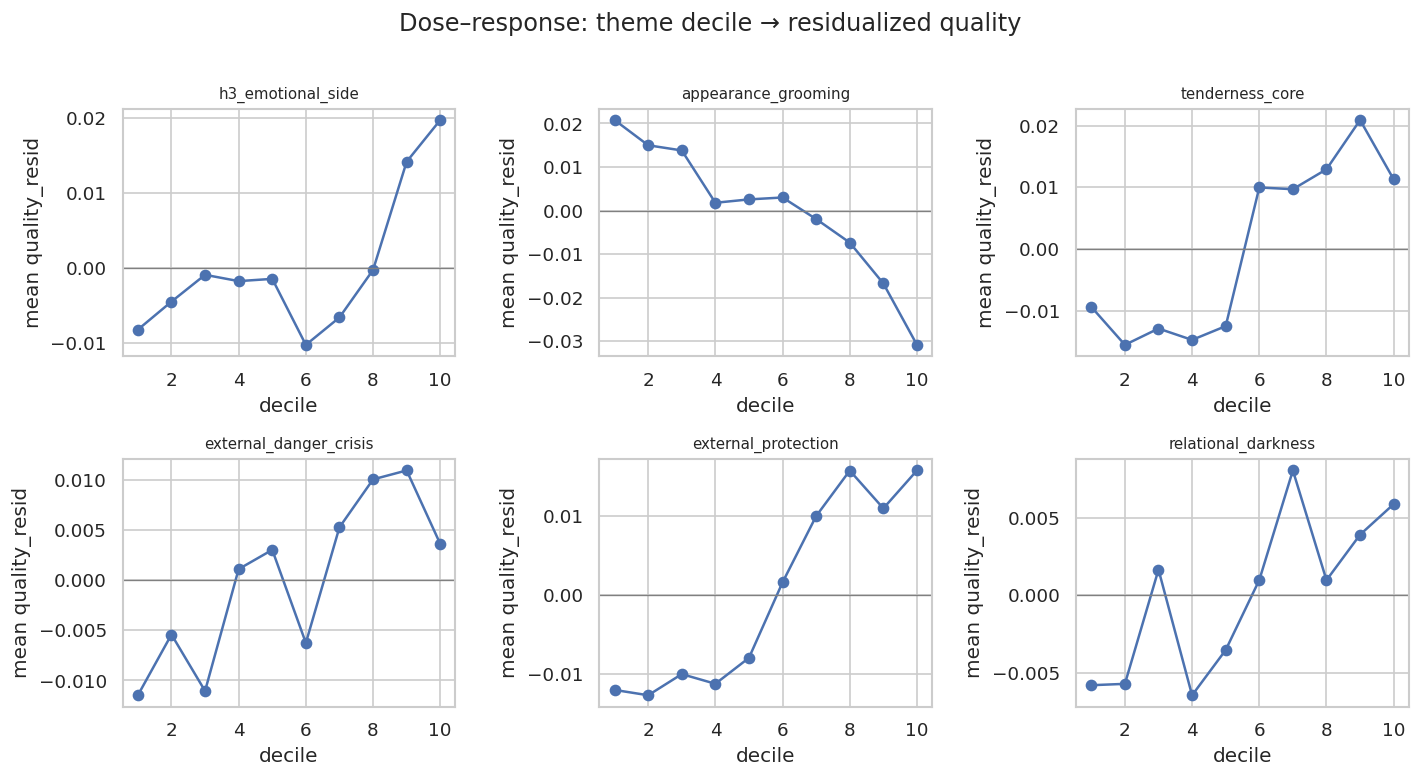

In [16]:
dose = pres.dose_response_panel(work, outcome="quality_resid", n_bins=10)
display(dose.head(20).round(4))
ctx.save_table(dose, "dose_response_curves")

if len(dose):
    features = dose["feature"].unique().tolist()
    n = len(features)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows), sharey=False)
    axes = np.atleast_1d(axes).ravel()
    for ax, feat in zip(axes, features):
        sub = dose[dose["feature"] == feat]
        ax.plot(sub["decile"], sub["outcome_mean"], marker="o")
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(feat.replace("RAX_", ""), fontsize=9)
        ax.set_xlabel("decile")
        ax.set_ylabel("mean quality_resid")
    for ax in axes[len(features) :]:
        ax.axis("off")
    fig.suptitle("Dose–response: theme decile → residualized quality", y=1.01)
    fig.tight_layout()
    ctx.save_figure(fig, "dose_response_curves")
    plt.show()

## Section 8 — Interactions

Reuse NB12 danger×protection (z-scored OLS + median-split 2×2) and care×appearance.
Conflict×repair removed: strict `RAX_repair` has no meaningful variation.

,protection_index,protection_col,z_danger_beta,z_danger_se,z_danger_p,z_protection_beta,z_protection_se,z_protection_p,z_danger_x_z_protection_beta,z_danger_x_z_protection_se,z_danger_x_z_protection_p
0,strict t119 only,EXP_enacted_protection_strict,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130
1,moderate + fractional,EXP_enacted_protection_moderate,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130
2,broad enacted,EXP_enacted_protection_broad,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/danger_x_protection_reused.csv  (3 rows)


,protection_index,protection_col,danger_bin,protection_bin,n,mean_rating,median_rating,danger_median_cut,protection_median_cut
0,strict t119 only,EXP_enacted_protection_strict,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
1,strict t119 only,EXP_enacted_protection_strict,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023
2,strict t119 only,EXP_enacted_protection_strict,lower_danger,higher_protection,3302,3.9289,3.9170,0.0067,0.0023
3,strict t119 only,EXP_enacted_protection_strict,lower_danger,lower_protection,4697,3.9007,3.9045,0.0067,0.0023
4,moderate + fractional,EXP_enacted_protection_moderate,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
5,moderate + fractional,EXP_enacted_protection_moderate,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023
6,moderate + fractional,EXP_enacted_protection_moderate,lower_danger,higher_protection,3302,3.9289,3.9170,0.0067,0.0023
7,moderate + fractional,EXP_enacted_protection_moderate,lower_danger,lower_protection,4697,3.9007,3.9045,0.0067,0.0023
8,broad enacted,EXP_enacted_protection_broad,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
9,broad enacted,EXP_enacted_protection_broad,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/danger_x_protection_quadrants_reused.csv  (12 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/danger_x_protection_heatmap_presentation.png


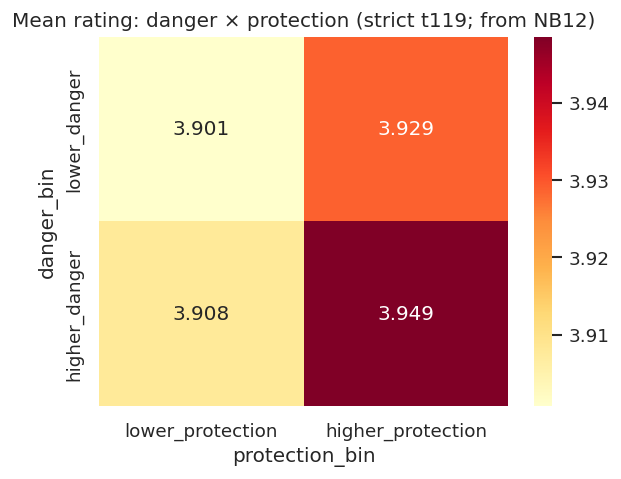

,_quad,rating_shrunk_mean,rating_shrunk_median,count
0,high_care_high_appearance,3.9131,3.9100,4275
1,high_care_low_appearance,3.9383,3.9245,3725
2,low_care_high_appearance,3.9056,3.9041,3725
3,low_care_low_appearance,3.9311,3.9174,4274


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/care_x_appearance_reused.csv  (4 rows)


In [17]:
if len(nb12_danger):
    display(nb12_danger.round(4))
    ctx.save_table(nb12_danger, "danger_x_protection_reused")
if len(nb12_danger_quad):
    display(nb12_danger_quad.round(4))
    ctx.save_table(nb12_danger_quad, "danger_x_protection_quadrants_reused")
    # Presentation heatmap: strict t119
    sub = nb12_danger_quad[nb12_danger_quad["protection_index"] == "strict t119 only"]
    if len(sub):
        mat = sub.pivot(index="danger_bin", columns="protection_bin", values="mean_rating")
        row_order = [r for r in ("lower_danger", "higher_danger") if r in mat.index]
        col_order = [c for c in ("lower_protection", "higher_protection") if c in mat.columns]
        mat = mat.reindex(index=row_order, columns=col_order)
        fig, ax = plt.subplots(figsize=(5.5, 4))
        sns.heatmap(mat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
        ax.set_title("Mean rating: danger × protection (strict t119; from NB12)")
        ctx.save_figure(fig, "danger_x_protection_heatmap_presentation")
        plt.show()
if len(nb12_care_app):
    display(nb12_care_app.round(4))
    ctx.save_table(nb12_care_app, "care_x_appearance_reused")

## Section 9 — Quality versus reach (refined constructs)

Standardised betas on both channels; quadrant labels.

channel,feature,quality,reach,quadrant
0,RARC,-0.0299,-0.0093,neither_or_opposite
1,RAX_appearance_grooming,-0.1517,0.0703,reach_only
2,RAX_emotional_reassurance,0.0745,0.1366,both
3,RAX_external_danger_crisis,0.0117,-0.0161,quality_only
4,RAX_external_protection,0.1089,-0.0110,quality_only
5,RAX_h3_emotional_side,0.0699,0.1292,both
6,RAX_h4_possession_side,0.0189,0.0027,both
7,RAX_nonexplicit_affection,0.0919,0.1333,both
8,RAX_tenderness_core,0.0919,0.1333,both
9,RLR_darkness_vs_tenderness,-0.1040,-0.1378,neither_or_opposite


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/quality_reach_standardized_betas.csv  (10 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/quality_reach_betas_long.csv  (20 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/quality_reach_quadrants.png


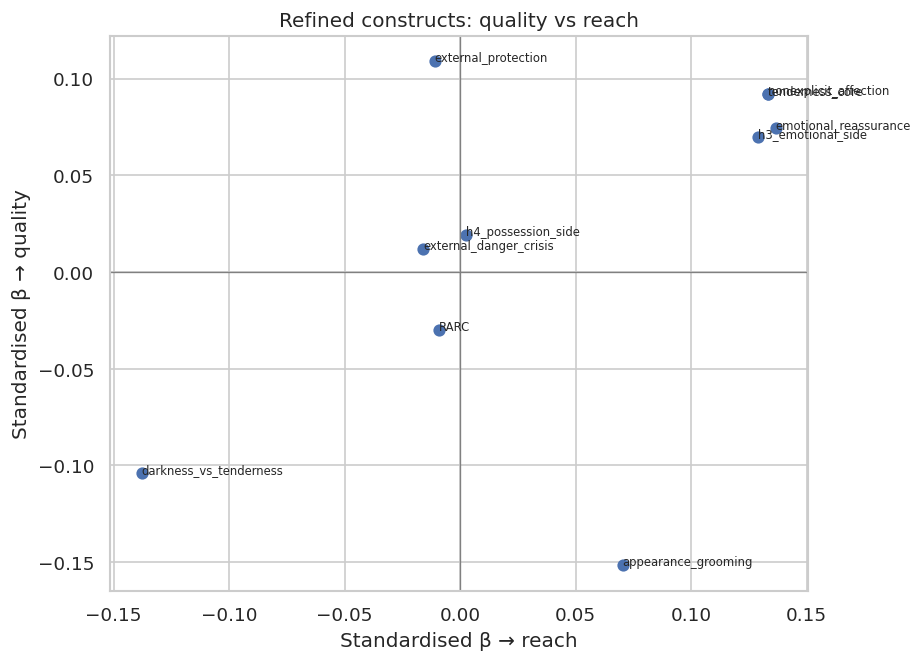

In [18]:
qr_feats = [f for f in HEADLINE if f in work.columns and nh.gate_for_feature(coverage, f) != "unmeasurable"]
betas = pres.standardized_two_channel_betas(work, qr_feats)
if len(betas):
    wide = betas.pivot(index="feature", columns="channel", values="beta_std").reset_index()
    if {"quality", "reach"} <= set(wide.columns):
        wide["quadrant"] = [
            pres.classify_quality_reach_quadrant(float(q), float(r))
            for q, r in zip(wide["quality"], wide["reach"])
        ]
    display(wide.round(4))
    ctx.save_table(wide, "quality_reach_standardized_betas")
    ctx.save_table(betas, "quality_reach_betas_long")

    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.scatter(wide["reach"], wide["quality"], s=40)
    for _, r in wide.iterrows():
        ax.annotate(str(r["feature"]).replace("RAX_", "").replace("RLR_", ""), (r["reach"], r["quality"]), fontsize=7)
    ax.set_xlabel("Standardised β → reach")
    ax.set_ylabel("Standardised β → quality")
    ax.set_title("Refined constructs: quality vs reach")
    ctx.save_figure(fig, "quality_reach_quadrants")
    plt.show()

## Section 10 — Residual Goodreads quadrants

Better/worse rated than expected × more/less reached than expected
(after year, length, genre).

In [19]:
quad_counts = work["residual_quadrant"].value_counts().rename_axis("quadrant").reset_index(name="n")
display(quad_counts)
ctx.save_table(quad_counts, "residual_quadrant_counts")

theme_means = pres.quadrant_theme_means(work, list(pres.ATTENTION_THEMES[i][0] for i in range(len(pres.ATTENTION_THEMES))))
display(theme_means.round(5))
ctx.save_table(theme_means, "residual_quadrant_theme_means")

# Cliff's δ of themes: stars vs popular_but_poor as a presentation contrast
from src.stage10_correlation_analysis.analysis.effects import cliffs_delta

contrast_rows = []
stars = work[work["residual_quadrant"] == "stars"]
poor_pop = work[work["residual_quadrant"] == "popular_but_poor"]
gems = work[work["residual_quadrant"] == "hidden_gems"]
for feat, label in pres.ATTENTION_THEMES:
    if feat not in work.columns:
        continue
    for name, a, b in (
        ("stars_vs_popular_but_poor", stars, poor_pop),
        ("hidden_gems_vs_low_low", gems, work[work["residual_quadrant"] == "low_low"]),
    ):
        aa = a[feat].dropna().to_numpy(dtype=float)
        bb = b[feat].dropna().to_numpy(dtype=float)
        if aa.size < 30 or bb.size < 30:
            continue
        contrast_rows.append(
            {
                "contrast": name,
                "feature": feat,
                "label": label,
                "cliffs_delta": float(cliffs_delta(aa, bb)),
                "n_a": int(aa.size),
                "n_b": int(bb.size),
            }
        )
contrast_df = pd.DataFrame(contrast_rows)
display(contrast_df.round(4))
ctx.save_table(contrast_df, "residual_quadrant_theme_deltas")

,quadrant,n
0,stars,4383
1,low_low,4382
2,popular_but_poor,3617
3,hidden_gems,3617


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/residual_quadrant_counts.csv  (4 rows)


,quadrant,n_books,RAX_h3_emotional_side,RAX_external_danger_crisis,RAX_tenderness_core,RAX_nonexplicit_affection,RAX_external_protection,RAX_repair,RAX_relational_darkness,RAX_explicit_sex,RAX_appearance_grooming,RAX_h4_possession_side
0,hidden_gems,3617,0.0322,0.0090,0.0160,0.0160,0.0029,0.0000,0.0630,0.0000,0.0153,0.0025
1,low_low,4382,0.0310,0.0094,0.0147,0.0147,0.0029,0.0000,0.0654,0.0000,0.0160,0.0025
2,popular_but_poor,3617,0.0340,0.0089,0.0176,0.0176,0.0027,0.0000,0.0669,0.0000,0.0172,0.0023
3,stars,4383,0.0359,0.0093,0.0191,0.0191,0.0031,0.0000,0.0680,0.0000,0.0158,0.0026


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/residual_quadrant_theme_means.csv  (4 rows)


,contrast,feature,label,cliffs_delta,n_a,n_b
0,stars_vs_popular_but_poor,RAX_h3_emotional_side,emotional reassurance/security,0.0470,4383,3617
1,hidden_gems_vs_low_low,RAX_h3_emotional_side,emotional reassurance/security,0.0312,3617,4382
2,stars_vs_popular_but_poor,RAX_external_danger_crisis,external danger,0.0772,4383,3617
3,hidden_gems_vs_low_low,RAX_external_danger_crisis,external danger,-0.0100,3617,4382
4,stars_vs_popular_but_poor,RAX_tenderness_core,tenderness,0.0757,4383,3617
5,hidden_gems_vs_low_low,RAX_tenderness_core,tenderness,0.0468,3617,4382
6,stars_vs_popular_but_poor,RAX_nonexplicit_affection,non-explicit affection,0.0757,4383,3617
7,hidden_gems_vs_low_low,RAX_nonexplicit_affection,non-explicit affection,0.0468,3617,4382
8,stars_vs_popular_but_poor,RAX_external_protection,enacted protection,0.1127,4383,3617
9,hidden_gems_vs_low_low,RAX_external_protection,enacted protection,-0.0128,3617,4382


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/residual_quadrant_theme_deltas.csv  (20 rows)


## Section 11 — Genre / era stability heatmap

,feature,group_type,group,cliffs_delta,n_high,n_low
0,RAX_h3_emotional_side,genre_group,historical,-0.0972,465,635
1,RAX_appearance_grooming,genre_group,historical,-0.1877,465,635
2,RAX_external_danger_crisis,genre_group,historical,0.2142,465,635
3,RAX_tenderness_core,genre_group,historical,-0.1704,465,635
4,RAX_explicit_sex,genre_group,historical,0.0000,465,635
5,RAX_external_protection,genre_group,historical,0.1126,465,635
6,RAX_h4_possession_side,genre_group,historical,-0.0975,465,635
7,RAX_nonexplicit_affection,genre_group,historical,-0.1704,465,635
8,RARC,genre_group,historical,-0.0964,465,635
9,RAX_h3_emotional_side,genre_group,mystery,0.1120,979,690


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/genre_era_subgroup_deltas.csv  (72 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/figures/genre_era_stability_heatmap.png


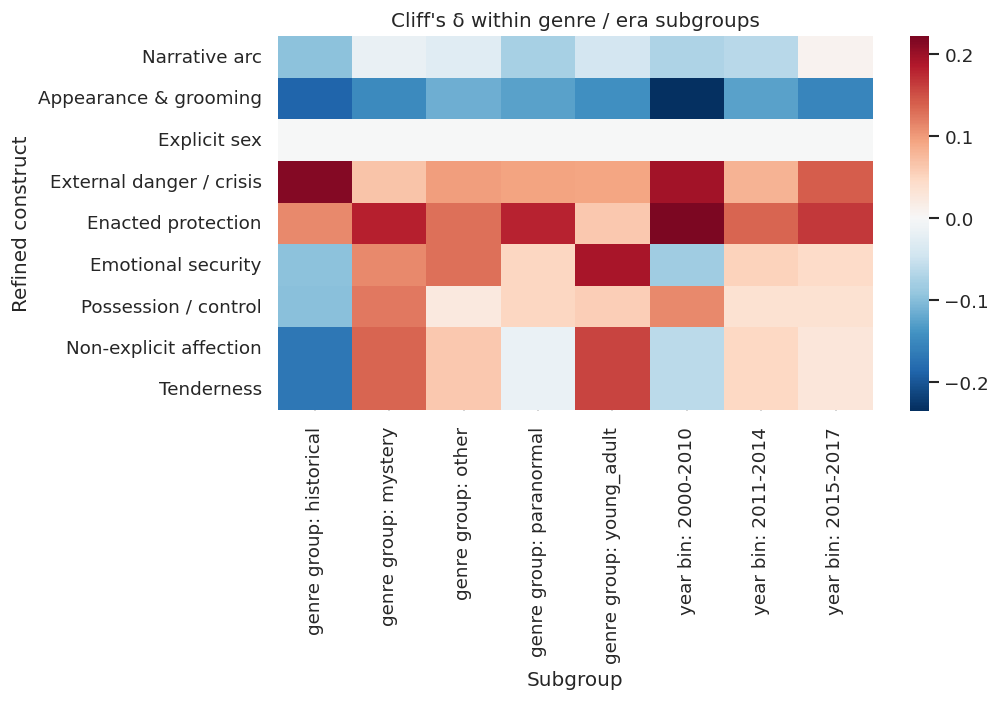

In [20]:
heat = pres.subgroup_cliffs_heatmap(work, list(pres.HEADLINE_THEMES_FOR_HEATMAP))
display(heat.head(20).round(4))
ctx.save_table(heat, "genre_era_subgroup_deltas")

_HEATMAP_HUMAN = {
    "RAX_h3_emotional_side": "Emotional security",
    "RAX_appearance_grooming": "Appearance & grooming",
    "RAX_external_danger_crisis": "External danger / crisis",
    "RAX_tenderness_core": "Tenderness",
    "RAX_explicit_sex": "Explicit sex",
    "RAX_external_protection": "Enacted protection",
    "RAX_h4_possession_side": "Possession / control",
    "RAX_nonexplicit_affection": "Non-explicit affection",
    "RARC": "Narrative arc",
}

if len(heat):
    heat["col"] = heat["group_type"].str.replace("_", " ") + ": " + heat["group"]
    mat = heat.pivot_table(index="feature", columns="col", values="cliffs_delta")
    mat.index = [_HEATMAP_HUMAN.get(f, f.replace("_", " ").capitalize()) for f in mat.index]
    fig, ax = plt.subplots(figsize=(max(8, 0.7 * mat.shape[1]), max(4, 0.45 * mat.shape[0])))
    sns.heatmap(mat, cmap="RdBu_r", center=0, ax=ax, annot=False)
    ax.set_xlabel("Subgroup")
    ax.set_ylabel("Refined construct")
    ax.set_title("Cliff's δ within genre / era subgroups")
    ctx.save_figure(fig, "genre_era_stability_heatmap")
    plt.show()

## Section 12 — Representative books and sentences

Deterministic 2×2 (high/low theme × high/low rating). Sentences from evidence packets
for the construct's mapped topics — fixed seed, no cherry-picking.

In [21]:
EXAMPLE_FEATURES = [
    "RAX_appearance_grooming",
    "RAX_h3_emotional_side",
    "RAX_external_danger_crisis",
    "RAX_external_protection",
]
example_books = []
example_sents = []
for feat in EXAMPLE_FEATURES:
    if feat not in work.columns:
        continue
    sampled = pres.sample_theme_book_cells(work, feat, books_per_cell=2, seed=42)
    sampled = sampled.assign(feature=feat)
    example_books.append(sampled.copy())
    # Attach one packet sentence from a KEEP topic when available
    # Appearance KEPT topics / emotional KEEP / danger uses forest topics / protection t119
    topic_map = {
        "RAX_appearance_grooming": [18, 77, 171],
        "RAX_h3_emotional_side": [46, 56, 29],
        "RAX_external_danger_crisis": [],
        "RAX_external_protection": [119],
    }
    tids = list(topic_map.get(feat) or [])
    if not tids and feat == "RAX_external_danger_crisis" and "topic_id" in master.columns:
        # Prefer topics already shown in NB12 forest if available
        if len(nb12_forest) and "topic_id" in nb12_forest.columns:
            tids = [int(t) for t in nb12_forest["topic_id"].dropna().tolist()[:3]]
    for tid in tids[:2]:
        card = pres.topic_presentation_card(cfg, tid, master)
        example_sents.append({"feature": feat, **card})

if example_books:
    books_df = pd.concat(example_books, ignore_index=True)
    display(books_df.head(20))
    ctx.save_table(books_df, "representative_books_2x2")
if example_sents:
    sents_df = pd.DataFrame(example_sents)
    display(sents_df)
    ctx.save_table(sents_df, "representative_topic_sentences")

print(
    "Notebook 14 complete. Exploratory only — does not alter Notebook 13 / H1–H6 verdicts."
)

,book_id,cell,RAX_appearance_grooming,rating_class,rating_shrunk,log_n_ratings,genre_group,publication_year,author_id,feature,RAX_h3_emotional_side,RAX_external_danger_crisis,RAX_external_protection
0,17291924,high_index_high_tier,0.0297,high_rate,3.9539,4.1431,young_adult,"2,011.0000",141588,RAX_appearance_grooming,NaN,NaN,NaN
1,47322478,high_index_high_tier,0.0345,high_rate,4.3184,9.1352,other,"2,016.0000",7226675,RAX_appearance_grooming,NaN,NaN,NaN
2,21856269,high_index_low_tier,0.0266,low_rate,3.4476,9.6849,other,"2,013.0000",6547908,RAX_appearance_grooming,NaN,NaN,NaN
3,21836019,high_index_low_tier,0.0261,low_rate,3.5414,5.6525,historical,"2,012.0000",5781880,RAX_appearance_grooming,NaN,NaN,NaN
4,44615873,low_index_high_tier,0.0067,high_rate,3.9480,3.4657,other,"2,015.0000",2899570,RAX_appearance_grooming,NaN,NaN,NaN
5,10885390,low_index_high_tier,0.0080,high_rate,4.2845,9.7906,mystery,"2,010.0000",24978,RAX_appearance_grooming,NaN,NaN,NaN
6,6244926,low_index_low_tier,0.0081,low_rate,3.7801,12.8219,paranormal,"2,009.0000",1330292,RAX_appearance_grooming,NaN,NaN,NaN
7,22007481,low_index_low_tier,0.0078,low_rate,3.8747,4.2485,paranormal,"2,012.0000",5929783,RAX_appearance_grooming,NaN,NaN,NaN
8,21388692,high_index_high_tier,NaN,high_rate,4.1375,10.0755,mystery,"2,012.0000",73977,RAX_h3_emotional_side,0.0608,NaN,NaN
9,46084482,high_index_high_tier,NaN,high_rate,4.3224,8.2759,other,"2,016.0000",5865943,RAX_h3_emotional_side,0.0624,NaN,NaN


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/representative_books_2x2.csv  (32 rows)


,feature,topic_id,topic_label,taxonomy_id,top_words,example_sentence
0,RAX_appearance_grooming,18,Ordering A Gown For Her,1.6,"dress, wear, clothes, wearing, dressed, gown, ...",
1,RAX_appearance_grooming,77,Haircut and Grooming Offered,1.6,"hair, blonde, blond, shave, shaved, brown, bla...","While he liked them both, the longer hair was ..."
2,RAX_h3_emotional_side,46,Asking Someone to Trust You,4.6,"trust, trusted, betrayed, betray, trusting, me...",Trust me.”
3,RAX_h3_emotional_side,56,Promising Never to Hurt You,4.6,"hurt, hurting, harm, mean, never, won, you, wa...",I have a tendency to hurt myself.
4,RAX_external_danger_crisis,68,Promising to Set Things Straight,9.2,"sutton, voice, said, had, nodded, prim, role, ...",Jack said. “
5,RAX_external_danger_crisis,78,Swearing War Before He Takes Her,7.2,"fight, fighting, war, battle, fought, fights, ...","The Scots have always loved a fight, haven’t t..."
6,RAX_external_protection,119,Offering to Keep Her Safe,4.6,"safe, protect, protection, dangerous, protecti...",I’m your man for getting you to the point of p...


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/14_exploratory_presentation_results/tables/representative_topic_sentences.csv  (7 rows)
Notebook 14 complete. Exploratory only — does not alter Notebook 13 / H1–H6 verdicts.
